In [1]:
# ==========================================================
# Notebook 07: Simple BESS price arbitrage
#
# Goal:
# Understand basic battery behavior before adding PV and EVs.
#
# Rule:
# - Charge when electricity price is low.
# - Discharge when electricity price is high.
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt

from scipy.io import loadmat

In [2]:
# ==========================================================
# Load yearly electricity price data
# ==========================================================

price_mat = loadmat("../data/raw/prices_yearly.mat")

price_year = price_mat["prices_all_year"].flatten()

print("Price data shape:", price_year.shape)

Price data shape: (8760,)


In [3]:
# ==========================================================
# Select one representative day
# ==========================================================

DAY = 95

price_day = price_year[
    (DAY - 1) * 24 : DAY * 24
]

hours = np.arange(24)

print("Selected day:", DAY)
print("Minimum price:", price_day.min())
print("Maximum price:", price_day.max())
print("Average price:", price_day.mean())

Selected day: 95
Minimum price: 0.04575
Maximum price: 0.10665000000000001
Average price: 0.06211125


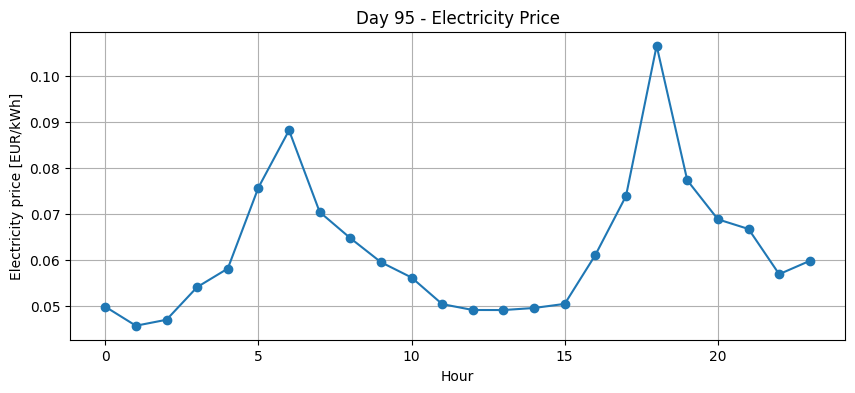

In [4]:
# ==========================================================
# Plot electricity price for the selected day
# ==========================================================

plt.figure(figsize=(10,4))

plt.plot(hours, price_day, marker="o")

plt.xlabel("Hour")
plt.ylabel("Electricity price [EUR/kWh]")
plt.title("Day 95 - Electricity Price")
plt.grid()

plt.show()

Define battery 

In [5]:
# ==========================================================
# Battery parameters
#
# We intentionally choose a small battery first.
# Later we will optimize the size.
# ==========================================================

E_bess = 200.0     # battery capacity [kWh]

P_bess_max = 50.0  # max charge/discharge power [kW]

eta_ch = 0.95      # charging efficiency
eta_dis = 0.95     # discharging efficiency

SOC_min = 0.10 * E_bess
SOC_max = 0.90 * E_bess

SOC0 = 0.50 * E_bess

print("Battery capacity [kWh]:", E_bess)
print("Initial SOC [kWh]:", SOC0)

Battery capacity [kWh]: 200.0
Initial SOC [kWh]: 100.0


In [6]:
# ==========================================================
# Simple charging/discharging thresholds
#
# Charge below average price
# Discharge above average price
#
# This is NOT optimization.
# It is a simple rule-based controller.
# ==========================================================

price_mean = price_day.mean()

charge_threshold = 0.90 * price_mean

discharge_threshold = 1.10 * price_mean

print("Average price:", price_mean)

print("Charge if price <", charge_threshold)
print("Discharge if price >", discharge_threshold)

Average price: 0.06211125
Charge if price < 0.055900125
Discharge if price > 0.068322375


Simulate the battery 

In [7]:
# ==========================================================
# Simple BESS simulation
#
# +P_bess = battery charging
# -P_bess = battery discharging
#
# SOC = energy stored inside battery
# ==========================================================

SOC = np.zeros(24)

P_bess = np.zeros(24)

SOC[0] = SOC0

for h in range(24):

    price = price_day[h]

    # ------------------------------------------------------
    # Charge battery when price is cheap
    # ------------------------------------------------------

    if price < charge_threshold:

        P_bess[h] = P_bess_max

    # ------------------------------------------------------
    # Discharge battery when price is expensive
    # ------------------------------------------------------

    elif price > discharge_threshold:

        P_bess[h] = -P_bess_max

    else:

        P_bess[h] = 0

    # ------------------------------------------------------
    # Update battery energy state
    # ------------------------------------------------------

    if h < 23:

        SOC[h+1] = SOC[h]

        # Charging

        if P_bess[h] > 0:

            SOC[h+1] += (
                P_bess[h] * eta_ch
            )

        # Discharging

        elif P_bess[h] < 0:

            SOC[h+1] += (
                P_bess[h] / eta_dis
            )

        # Respect SOC limits

        SOC[h+1] = np.clip(
            SOC[h+1],
            SOC_min,
            SOC_max
        )

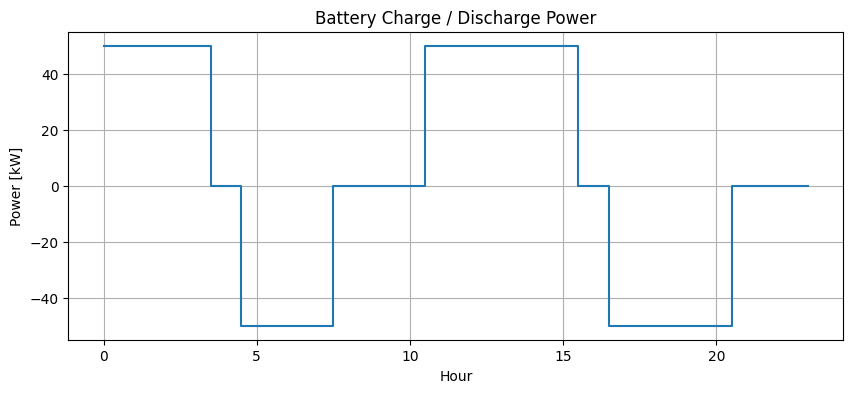

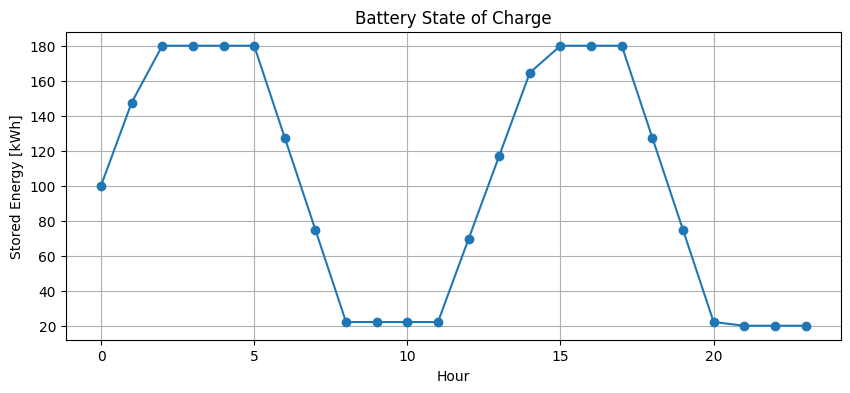

In [8]:
# ==========================================================
# Plot battery power and SOC
# ==========================================================

plt.figure(figsize=(10,4))

plt.step(
    hours,
    P_bess,
    where="mid"
)

plt.title("Battery Charge / Discharge Power")
plt.xlabel("Hour")
plt.ylabel("Power [kW]")
plt.grid()

plt.show()


plt.figure(figsize=(10,4))

plt.plot(
    hours,
    SOC,
    marker="o"
)

plt.title("Battery State of Charge")
plt.xlabel("Hour")
plt.ylabel("Stored Energy [kWh]")
plt.grid()

plt.show()